# Phân tích Lưu lượng truy cập và Tỉ lệ chuyển đổi (2013-2022)

## Bước 1: Liệt kê tệp dữ liệu và Đọc hiểu cột dữ liệu
Đọc 2 bảng dữ liệu chính `web_traffic.csv` và `orders.csv` để chuẩn bị cho quá trình biến đổi dữ liệu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Tải dữ liệu
df_traffic = pd.read_csv('../../data/web_traffic.csv')
df_orders = pd.read_csv('../../data/orders.csv')

# Trích xuất năm
df_traffic['date'] = pd.to_datetime(df_traffic['date'])
df_traffic['Year'] = df_traffic['date'].dt.year

df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['Year'] = df_orders['order_date'].dt.year

print("Đã tải thành công dữ liệu và trích xuất cột Năm!")

Đã tải thành công dữ liệu và trích xuất cột Năm!


## Bước 2: Công thức Toán học cần dùng

Chúng ta sẽ tính Conversion Rate bằng công thức:
$$ \text{Tổng Lượng Traffic} = \sum \text{Sessions} $$
$$ \text{Tổng Đơn Hàng (Orders)} = \sum (\text{Số lượng order\_id duy nhất}) $$
$$ \text{Conversion Rate} = \left( \frac{\text{Tổng Đơn Hàng}}{\text{Tổng Lượng Traffic}} \right) \times 100\% $$

## Bước 3: Hướng xử lý dữ liệu (Data Pipeline)

Thực hiện lọc dữ liệu từ 2013-2022, gom nhóm theo `Year` và nguồn dẫn, sau đó Join và tính toán `Conversion Rate`.

In [2]:
# 1. Lọc thời gian 2013 - 2022
df_traffic = df_traffic[(df_traffic['Year'] >= 2013) & (df_traffic['Year'] <= 2022)]
df_orders = df_orders[(df_orders['Year'] >= 2013) & (df_orders['Year'] <= 2022)]

# 2. Gom nhóm (Aggregation)
traffic_grouped = df_traffic.groupby(['Year', 'traffic_source'])['sessions'].sum().reset_index()
orders_grouped = df_orders.groupby(['Year', 'order_source'])['order_id'].nunique().reset_index()

# Đổi tên order_source thành traffic_source để chuẩn bị cho việc Nối dữ liệu (Join)
orders_grouped.rename(columns={'order_source': 'traffic_source'}, inplace=True)

# 3. Nối dữ liệu (Join)
df_merged = pd.merge(traffic_grouped, orders_grouped, on=['Year', 'traffic_source'], how='left')
df_merged['order_id'] = df_merged['order_id'].fillna(0) # Xử lý NaN thành 0

# 4. Tính toán
df_merged['conversion_rate'] = (df_merged['order_id'] / df_merged['sessions']) * 100
df_merged['conversion_rate'] = df_merged['conversion_rate'].fillna(0)

df_merged.head(20)

,Year,traffic_source,sessions,order_id,conversion_rate
0,2013,direct,572205,6158,1.076188
1,2013,email_campaign,617016,9436,1.529296
2,2013,organic_search,2210897,21625,0.978110
3,2013,paid_search,1446505,16734,1.156857
4,2013,referral,552863,7673,1.387866
5,2013,social_media,1402454,15223,1.085454
6,2014,direct,725561,6457,0.889932
7,2014,email_campaign,766279,9609,1.253982
8,2014,organic_search,1980652,22666,1.144371
9,2014,paid_search,1808610,17622,0.974339


## Bước 4: Thiết lập Biểu đồ (Visual Configurations)

Vẽ biểu đồ Bar Chart kết hợp Line Chart với trục Y kép, thiết lập màu sắc đồng bộ và chú thích dữ liệu nổi bật tại các điểm chóp.

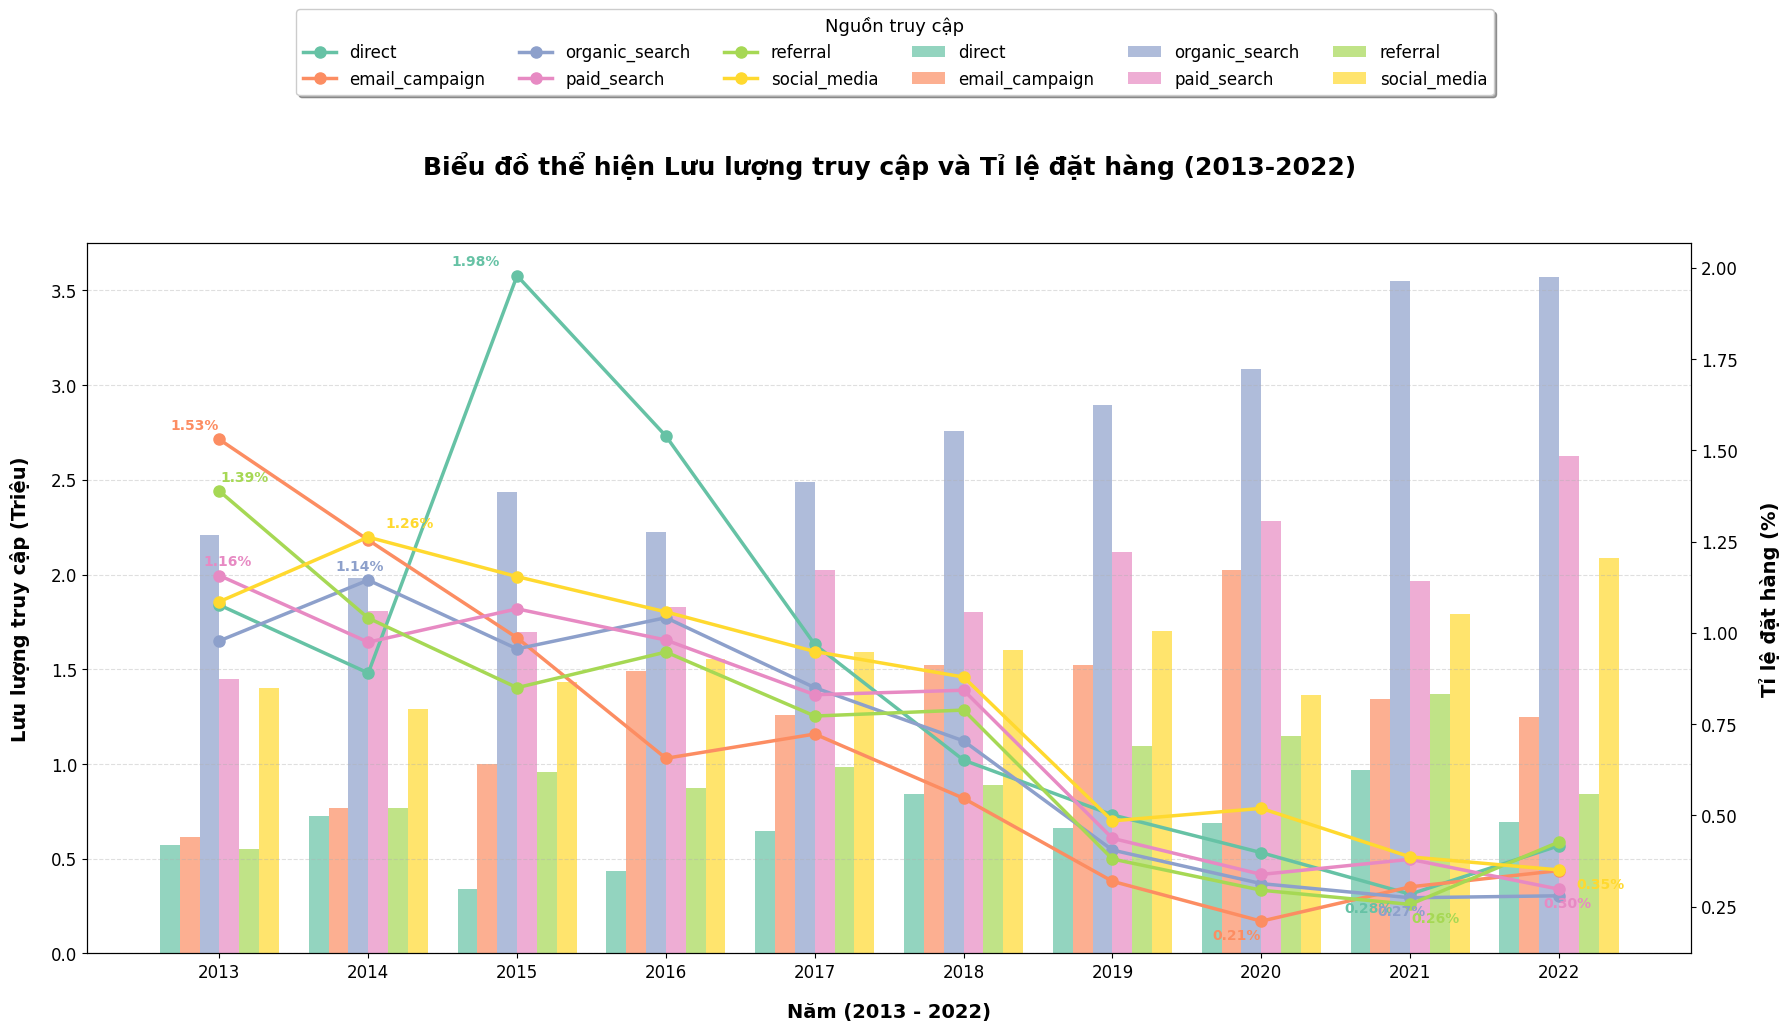

In [3]:
# Thiết lập biểu đồ tổng thể (chuẩn học thuật)
plt.style.use('default')
fig, ax1 = plt.subplots(figsize=(18, 9))

# Chuẩn bị dữ liệu trục X
years = sorted(df_merged['Year'].unique())
sources = sorted(df_merged['traffic_source'].unique())
x = np.arange(len(years))
width = 0.8 / len(sources)  # Độ rộng linh hoạt của mỗi bar

# Đồng bộ màu sắc cho 6 kênh traffic_source
colors = sns.color_palette("Set2", len(sources))
color_dict = dict(zip(sources, colors))

# --- TRỤC Y BÊN TRÁI: Barchart (Lưu lượng truy cập) ---
for i, source in enumerate(sources):
    source_data = df_merged[df_merged['traffic_source'] == source]
    # Merge để đảm bảo đủ các năm, nếu thiếu thì điền 0
    source_data = pd.DataFrame({'Year': years}).merge(source_data, on='Year', how='left').fillna({'sessions': 0, 'conversion_rate': 0})
    
    offset = (i - len(sources)/2 + 0.5) * width
    ax1.bar(x + offset, source_data['sessions'] / 1000000, width, color=color_dict[source], alpha=0.7, label=source)

ax1.set_xlabel('Năm (2013 - 2022)', fontsize=14, fontweight='bold', labelpad=15)
ax1.set_ylabel('Lưu lượng truy cập (Triệu)', fontsize=14, fontweight='bold', labelpad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=12)
ax1.tick_params(axis='y', labelsize=12)

# --- TRỤC Y BÊN PHẢI: Line Chart (Conversion Rate) ---
ax2 = ax1.twinx()

for i, source in enumerate(sources):
    source_data = df_merged[df_merged['traffic_source'] == source]
    source_data = pd.DataFrame({'Year': years}).merge(source_data, on='Year', how='left').fillna({'sessions': 0, 'conversion_rate': 0})
    
    # Vẽ đường (Line) kết hợp dấu chấm (Marker)
    ax2.plot(x, source_data['conversion_rate'], marker='o', linewidth=2.5, markersize=8,
             label=source, color=color_dict[source])
    
    # Xác định đỉnh cao nhất và thấp nhất để gắn Data Labels
    if source_data['conversion_rate'].max() > 0:
        max_idx = source_data['conversion_rate'].idxmax()
        min_idx = source_data['conversion_rate'].idxmin()
        
        max_val = source_data.loc[max_idx, 'conversion_rate']
        min_val = source_data.loc[min_idx, 'conversion_rate']
        
        # Đẩy lệch ngang mỗi nguồn để giảm chồng chéo nhãn
        text_dx = int((i - len(sources) / 2 + 0.5) * 12)
        
        # Label Max
        ax2.annotate(
            f'{max_val:.2f}%', xy=(x[max_idx], max_val), xytext=(text_dx, 5),
            textcoords='offset points', ha='center', va='bottom', fontsize=10,
            color=color_dict[source], fontweight='bold',

        )
        # Label Min (nếu khác Max để tránh trùng lặp)
        if min_val != max_val and min_val > 0:
            ax2.annotate(
                f'{min_val:.2f}%', xy=(x[min_idx], min_val), xytext=(text_dx, -5),
                textcoords='offset points', ha='center', va='top', fontsize=10,
                color=color_dict[source], fontweight='bold',

            )

ax2.set_ylabel('Tỉ lệ đặt hàng (%)', fontsize=14, fontweight='bold', labelpad=15)
ax2.tick_params(axis='y', labelsize=12)

# --- Cấu hình chung ---
# Đặt Legend đồng bộ ở trên cùng biểu đồ
handles2, labels2 = ax2.get_legend_handles_labels()
handles1, labels1 = ax1.get_legend_handles_labels()
handles = handles2 + handles1
labels = labels2 + labels1
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=6, 
           title="Nguồn truy cập", fontsize=12, title_fontsize=13, frameon=True, shadow=True)

# Tiêu đề
plt.title('Biểu đồ thể hiện Lưu lượng truy cập và Tỉ lệ đặt hàng (2013-2022)', 
          fontsize=18, fontweight='bold', pad=50)

# Cải thiện độ rõ nét của lưới trục Y bên trái
ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()